# DeCaL vs FullDeCaL: Systematic Comparison on UMLS & KINSHIP

**Research questions:**
1. **Q1 — Does full Clifford configuration help?**  
   Compare DeCaL (1+n blade approximation) vs FullDeCaL-fixed (2^n blades) at *equal parameter count* across 5 Clifford signatures.
2. **Q2 — Is auto-signature discovery effective across embedding dimensions?**  
   Does FullDeCaL-auto find a competitive algebra as `n` changes with `embedding_dim`?

> **Run experiments first:**  
> `python experiments/decal_comparison.py --epochs 100`  
> Then re-run this notebook to populate all plots.

All results are read from `experiments/results/comparison_results.csv`.


## 1. Imports & Paths

In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Paths ──────────────────────────────────────────────────────────────────
REPO        = Path(os.getcwd()).parent if Path(os.getcwd()).name == "experiments" else Path(os.getcwd())
RESULTS_CSV = REPO / "experiments" / "results" / "comparison_results.csv"

if not RESULTS_CSV.exists():
    print(f"⚠  No results yet.  Run:\n"
          f"   python experiments/decal_comparison.py --dry_run\n"
          f"   python experiments/decal_comparison.py --epochs 100\n")
else:
    print(f"✓  Results found: {RESULTS_CSV}  ({RESULTS_CSV.stat().st_size // 1024} KB)")

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
PALETTE = {
    "DeCaL":           "#4C72B0",
    "FullDeCaL-fixed": "#DD8452",
    "FullDeCaL-auto":  "#55A868",
}
METRICS = ["Test_MRR", "Test_H@1", "Test_H@3", "Test_H@10"]

def n_from_dim(d: int) -> int:
    """Auto-derived n: floor(log2(d) / 2), decremented until 2^n divides d."""
    n = max(1, int(math.log2(d)) // 2)
    while d % (1 << n) != 0:
        n -= 1
    return n

print("n per dim:", {d: n_from_dim(d) for d in [32, 64, 128, 256]})


✓  Results found: /home/dice/Downloads/dice-embeddings/experiments/results/comparison_results.csv  (8 KB)
n per dim: {32: 2, 64: 3, 128: 3, 256: 4}


## 2. Load & Tidy Results

In [6]:
df_raw = pd.read_csv(RESULTS_CSV)

# ── Normalise column names (eval_report uses "Test" capitalized) ──────────
df_raw.columns = [c.replace("Test_H@", "Test_H@") for c in df_raw.columns]

# ── Derive a display-friendly "method" column ─────────────────────────────
def method_label(row):
    if row["model"] == "DeCaL":
        return "DeCaL"
    if row["signature"] == "auto":
        return "FullDeCaL-auto"
    return "FullDeCaL-fixed"

df_raw["method"] = df_raw.apply(method_label, axis=1)

# ── Confirm columns ───────────────────────────────────────────────────────
metric_cols = [c for c in df_raw.columns if c.startswith("Test_")]
print("Metric columns:", metric_cols)
print(f"Rows: {len(df_raw)}  |  Datasets: {df_raw['dataset'].unique()}")
df_raw[["dataset","question","method","signature","embedding_dim"] + metric_cols].head(10)


Metric columns: ['Test_H@1', 'Test_H@3', 'Test_H@10', 'Test_MRR']
Rows: 46  |  Datasets: <ArrowStringArray>
['UMLS', 'KINSHIP']
Length: 2, dtype: str


,dataset,question,method,signature,embedding_dim,Test_H@1,Test_H@3,Test_H@10,Test_MRR
0,UMLS,Q1,DeCaL,"Cl(3,0,0)",64,0.39334,0.65204,0.88654,0.55885
1,UMLS,Q1,FullDeCaL-fixed,"Cl(3,0,0)",64,0.49017,0.74660,0.90923,0.63912
2,UMLS,Q1,DeCaL,"Cl(0,3,0)",64,0.48714,0.72466,0.91074,0.63012
3,UMLS,Q1,FullDeCaL-fixed,"Cl(0,3,0)",64,0.44781,0.70877,0.90923,0.60496
4,UMLS,Q1,DeCaL,"Cl(1,1,1)",64,0.39107,0.62179,0.87065,0.54127
5,UMLS,Q1,FullDeCaL-fixed,"Cl(1,1,1)",64,0.51286,0.74206,0.92209,0.65387
6,UMLS,Q1,DeCaL,"Cl(2,1,0)",64,0.40469,0.67474,0.88956,0.56807
7,UMLS,Q1,FullDeCaL-fixed,"Cl(2,1,0)",64,0.53101,0.75719,0.93268,0.66801
8,UMLS,Q1,DeCaL,"Cl(0,0,3)",64,0.38427,0.63011,0.88502,0.54300
9,UMLS,Q1,FullDeCaL-fixed,"Cl(0,0,3)",64,0.57413,0.78820,0.92663,0.69900


## 3. Q1 — Does Full Clifford Configuration Help?

**Setup:** `embedding_dim=64` fixed. Five Clifford signatures tested.  
*Parameter count parity:* DeCaL uses 4 component vectors × re=16; FullDeCaL uses 8 blade vectors × re=8.  Both have 64 parameters per embedding slot.

The key architectural difference is interaction coverage:
- **DeCaL** computes products between 1+n=4 components (linear in n blade interactions)
- **FullDeCaL** computes products between all 2^n=8 blades ($2^{2n}$ interaction pairs)


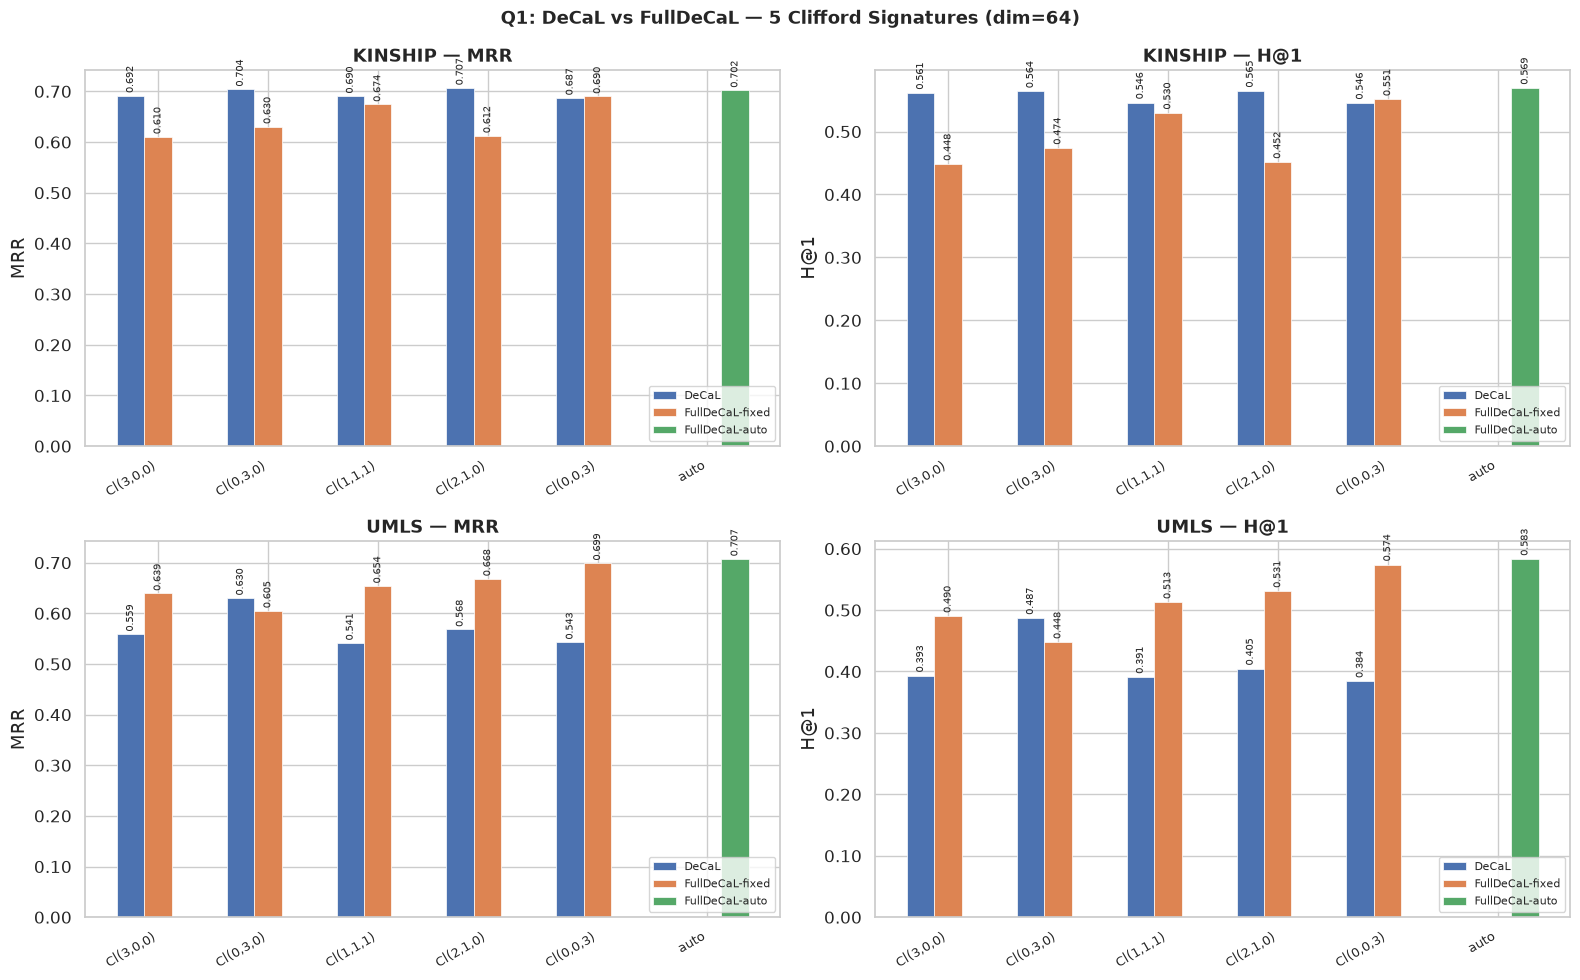

Saved → experiments/results/q1_signature_comparison.png


In [7]:
q1 = df_raw[df_raw["question"] == "Q1"].copy()

# Order signatures: fixed ones first, auto last
sig_order = ["Cl(3,0,0)", "Cl(0,3,0)", "Cl(1,1,1)", "Cl(2,1,0)", "Cl(0,0,3)", "auto"]
q1["signature"] = pd.Categorical(q1["signature"], categories=sig_order, ordered=True)
q1 = q1.sort_values("signature")

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax_idx, (dataset, grp) in enumerate(q1.groupby("dataset")):
    for metric_idx, metric in enumerate(["Test_MRR", "Test_H@1"]):
        ax = axes[ax_idx * 2 + metric_idx]
        pivot = grp.pivot_table(index="signature", columns="method", values=metric)
        # Ensure column order
        col_order = [c for c in ["DeCaL", "FullDeCaL-fixed", "FullDeCaL-auto"] if c in pivot.columns]
        pivot = pivot[col_order]

        x = np.arange(len(pivot))
        width = 0.25
        for i, col in enumerate(col_order):
            bars = ax.bar(x + i * width, pivot[col], width,
                          label=col, color=list(PALETTE.values())[i],
                          edgecolor="white", linewidth=0.5)
            # Annotate top of bar
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h):
                    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                            f"{h:.3f}", ha="center", va="bottom", fontsize=7, rotation=90)

        ax.set_xticks(x + width)
        ax.set_xticklabels(pivot.index, rotation=30, ha="right", fontsize=9)
        ax.set_title(f"{dataset} — {metric.replace('Test_', '')}", fontweight="bold")
        ax.set_ylabel(metric.replace("Test_", ""))
        ax.legend(fontsize=8, loc="lower right")
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

fig.suptitle("Q1: DeCaL vs FullDeCaL — 5 Clifford Signatures (dim=64)", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(RESULTS_CSV.parent / "q1_signature_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → experiments/results/q1_signature_comparison.png")


In [8]:
# Delta table: FullDeCaL-fixed minus DeCaL for same signature (Q1 answer)
def compute_delta_q1(q1_df, metric="Test_MRR"):
    rows = []
    for (dataset, sig), grp in q1_df[q1_df["signature"] != "auto"].groupby(["dataset", "signature"]):
        decal_val   = grp.loc[grp["method"] == "DeCaL",           metric].values
        full_val    = grp.loc[grp["method"] == "FullDeCaL-fixed",  metric].values
        auto_val    = q1_df[(q1_df["dataset"] == dataset) & (q1_df["signature"] == "auto")][metric].values
        rows.append({
            "dataset":   dataset,
            "signature": sig,
            f"DeCaL {metric}":          decal_val[0] if len(decal_val) else float("nan"),
            f"FullDeCaL-fixed {metric}": full_val[0] if len(full_val)  else float("nan"),
            f"FullDeCaL-auto {metric}":  auto_val[0] if len(auto_val)  else float("nan"),
        })
    delta_df = pd.DataFrame(rows)
    delta_df["Δ fixed−DeCaL"]  = delta_df[f"FullDeCaL-fixed {metric}"] - delta_df[f"DeCaL {metric}"]
    delta_df["Δ auto−DeCaL"]   = delta_df[f"FullDeCaL-auto {metric}"]  - delta_df[f"DeCaL {metric}"]
    return delta_df

delta_mrr = compute_delta_q1(q1, "Test_MRR")
print("Test MRR delta (FullDeCaL − DeCaL):")
print(delta_mrr.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


Test MRR delta (FullDeCaL − DeCaL):
dataset signature  DeCaL Test_MRR  FullDeCaL-fixed Test_MRR  FullDeCaL-auto Test_MRR  Δ fixed−DeCaL  Δ auto−DeCaL
KINSHIP Cl(3,0,0)         +0.6916                   +0.6103                  +0.7020        -0.0813       +0.0103
KINSHIP Cl(0,3,0)         +0.7042                   +0.6304                  +0.7020        -0.0738       -0.0022
KINSHIP Cl(1,1,1)         +0.6904                   +0.6741                  +0.7020        -0.0163       +0.0116
KINSHIP Cl(2,1,0)         +0.7067                   +0.6123                  +0.7020        -0.0944       -0.0048
KINSHIP Cl(0,0,3)         +0.6869                   +0.6898                  +0.7020        +0.0030       +0.0151
   UMLS Cl(3,0,0)         +0.5588                   +0.6391                  +0.7074        +0.0803       +0.1485
   UMLS Cl(0,3,0)         +0.6301                   +0.6050                  +0.7074        -0.0252       +0.0772
   UMLS Cl(1,1,1)         +0.5413                   

## 4. Q1 — Signature Sensitivity Heatmap

Which Clifford signature is best for which dataset/model combination?

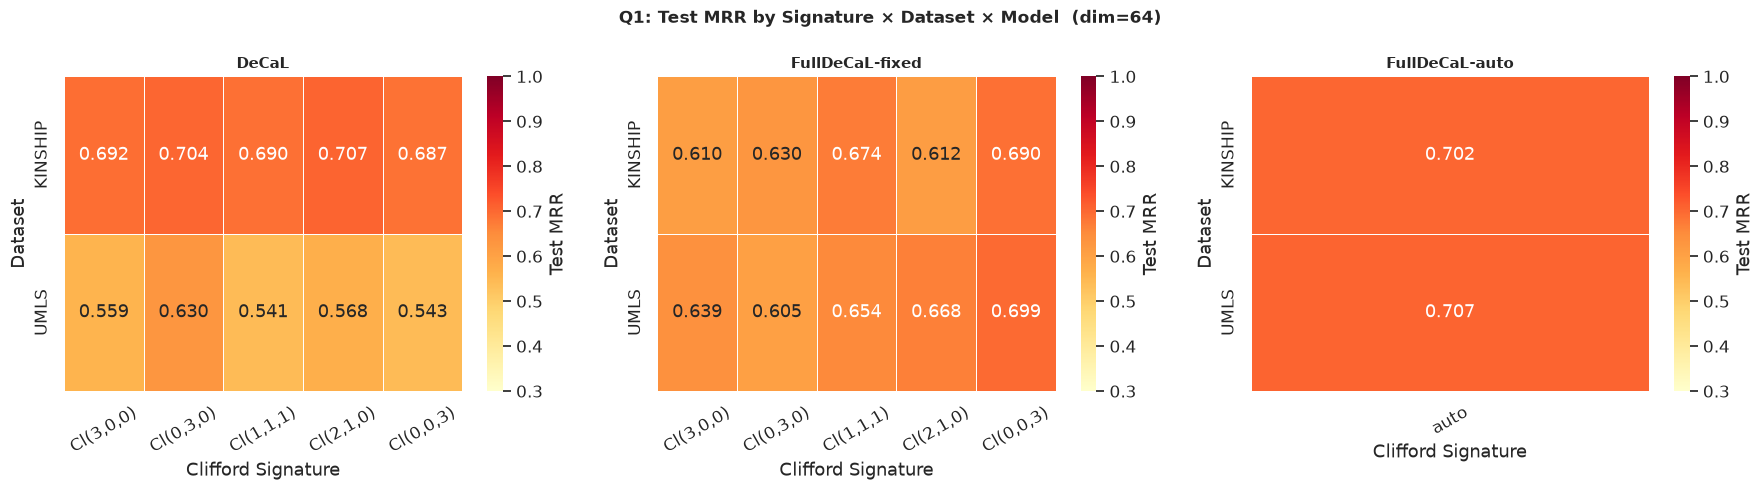

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ["DeCaL", "FullDeCaL-fixed", "FullDeCaL-auto"]):
    sub = q1[q1["method"] == method]
    if sub.empty:
        ax.set_visible(False)
        continue
    pivot = sub.pivot_table(index="dataset", columns="signature", values="Test_MRR")
    # Put auto column last if present
    sig_cols = [s for s in sig_order if s in pivot.columns]
    pivot = pivot[sig_cols]

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
        vmin=0.3, vmax=1.0, linewidths=0.5,
        cbar_kws={"label": "Test MRR"},
    )
    ax.set_title(f"{method}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Clifford Signature")
    ax.set_ylabel("Dataset")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Q1: Test MRR by Signature × Dataset × Model  (dim=64)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig(RESULTS_CSV.parent / "q1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Q2 — Auto-Signature Discovery Across Embedding Dimensions

Line plots of Test MRR vs `embedding_dim` for three model variants.  
Secondary axis shows the auto-derived `n` (number of generators) at each dimension.

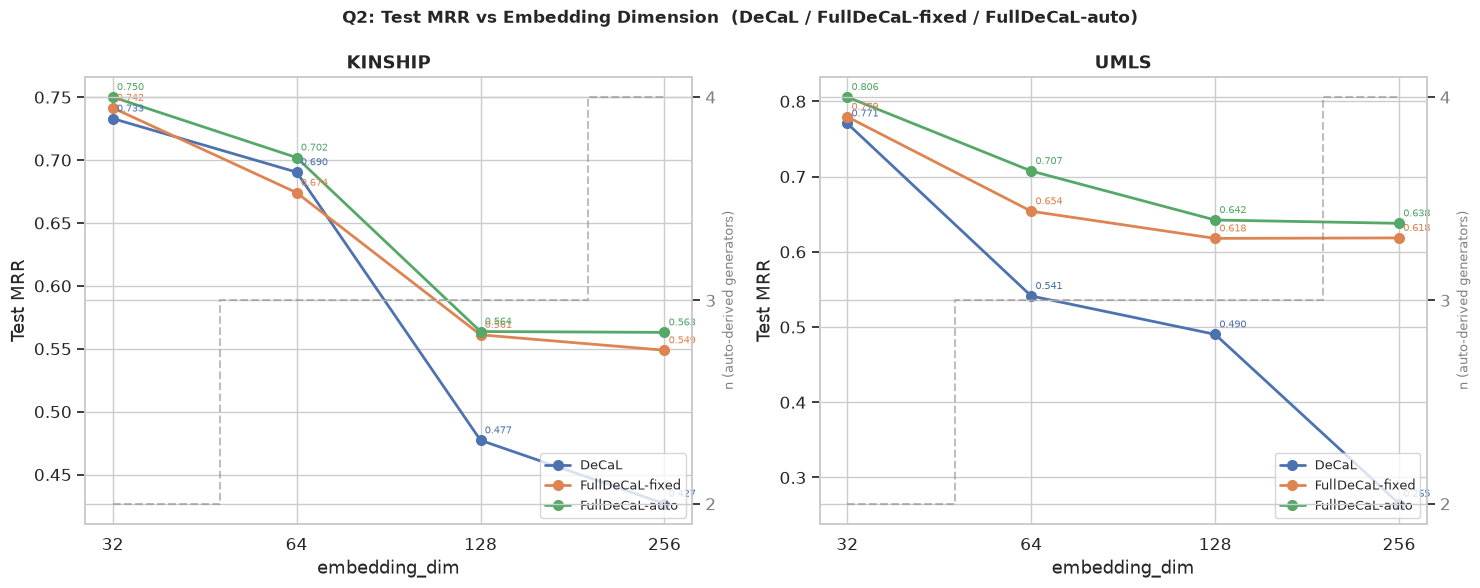

In [10]:
q2 = df_raw[df_raw["question"] == "Q2"].copy()
dims = sorted(q2["embedding_dim"].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, dataset in zip(axes, sorted(q2["dataset"].unique())):
    grp = q2[q2["dataset"] == dataset]
    ax2 = ax.twinx()   # secondary axis for n

    for method, color in PALETTE.items():
        sub = grp[grp["method"] == method].sort_values("embedding_dim")
        if sub.empty:
            continue
        ax.plot(sub["embedding_dim"], sub["Test_MRR"],
                marker="o", linewidth=2, markersize=7,
                color=color, label=method)
        # Annotate each point with MRR value
        for _, row in sub.iterrows():
            ax.annotate(f"{row['Test_MRR']:.3f}",
                        xy=(row["embedding_dim"], row["Test_MRR"]),
                        xytext=(3, 5), textcoords="offset points",
                        fontsize=7, color=color)

    # Overlay n on secondary axis
    n_vals = [n_from_dim(d) for d in dims]
    ax2.step(dims, n_vals, where="mid", linestyle="--", color="grey",
             alpha=0.5, linewidth=1.5)
    ax2.set_ylabel("n (auto-derived generators)", color="grey", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="grey")
    ax2.set_yticks(sorted(set(n_vals)))
    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

    ax.set_xscale("log", base=2)
    ax.set_xticks(dims)
    ax.set_xticklabels([str(d) for d in dims])
    ax.set_xlabel("embedding_dim")
    ax.set_ylabel("Test MRR")
    ax.set_title(f"{dataset}", fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Q2: Test MRR vs Embedding Dimension  (DeCaL / FullDeCaL-fixed / FullDeCaL-auto)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig(RESULTS_CSV.parent / "q2_dim_scaling.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Q2 — Auto vs Fixed Gap (ΔMRR) per Dim

$\Delta_\text{MRR} = \text{MRR}_\text{auto} - \text{MRR}_\text{best-fixed}$  
Positive = auto wins; Negative = a fixed signature is better.


dataset  embedding_dim  n  auto_MRR  best_fixed_MRR  Δ auto−best_fixed
KINSHIP             32  2   +0.7501         +0.7415            +0.0086
KINSHIP             64  3   +0.7020         +0.6904            +0.0116
KINSHIP            128  3   +0.5637         +0.5611            +0.0026
KINSHIP            256  4   +0.5630         +0.5488            +0.0142
   UMLS             32  2   +0.8057         +0.7794            +0.0263
   UMLS             64  3   +0.7074         +0.6539            +0.0535
   UMLS            128  3   +0.6422         +0.6178            +0.0244
   UMLS            256  4   +0.6378         +0.6184            +0.0194


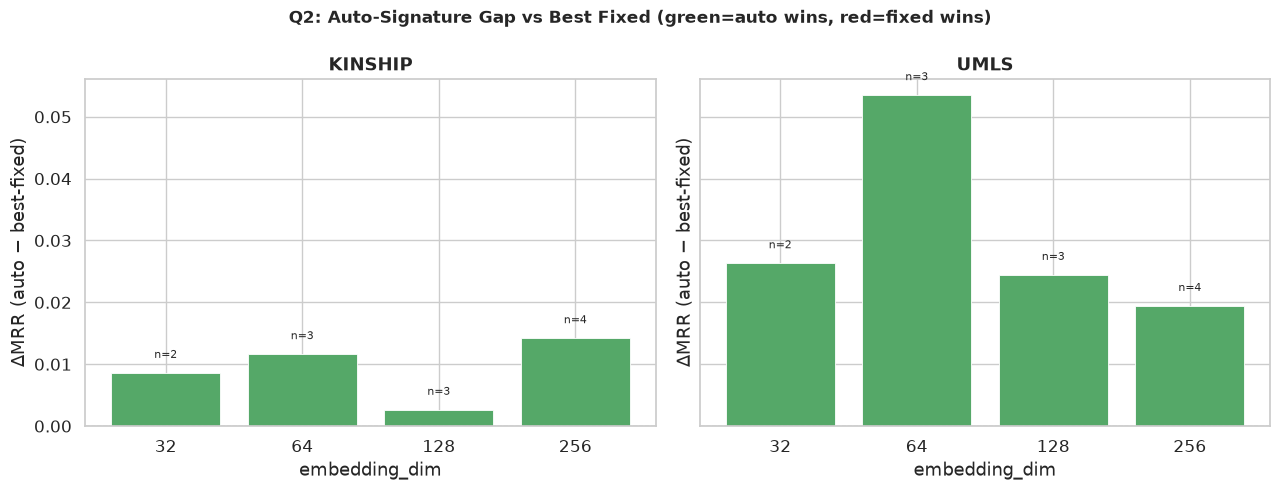

In [11]:
delta_rows = []
for (dataset, dim), grp in q2.groupby(["dataset", "embedding_dim"]):
    auto_mrr  = grp.loc[grp["method"] == "FullDeCaL-auto",  "Test_MRR"].values
    fixed_mrr = grp.loc[grp["method"] == "FullDeCaL-fixed", "Test_MRR"].values
    decal_mrr = grp.loc[grp["method"] == "DeCaL",           "Test_MRR"].values
    best_fixed = max([v for v in list(fixed_mrr) + list(decal_mrr) if not np.isnan(v)], default=float("nan"))
    delta_rows.append({
        "dataset":       dataset,
        "embedding_dim": dim,
        "n":             n_from_dim(dim),
        "auto_MRR":      auto_mrr[0]  if len(auto_mrr)  else float("nan"),
        "best_fixed_MRR":best_fixed,
        "Δ auto−best_fixed": (auto_mrr[0] - best_fixed) if len(auto_mrr) else float("nan"),
    })

delta_q2 = pd.DataFrame(delta_rows)
print(delta_q2.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, dataset in zip(axes, sorted(delta_q2["dataset"].unique())):
    sub = delta_q2[delta_q2["dataset"] == dataset].sort_values("embedding_dim")
    colors = ["#55A868" if v >= 0 else "#C44E52" for v in sub["Δ auto−best_fixed"]]
    bars = ax.bar(sub["embedding_dim"].astype(str), sub["Δ auto−best_fixed"],
                  color=colors, edgecolor="white", linewidth=0.6)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.002 if bar.get_height() >= 0 else -0.006),
                f"n={row['n']}", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("embedding_dim")
    ax.set_ylabel("ΔMRR (auto − best-fixed)")
    ax.set_title(f"{dataset}", fontweight="bold")

fig.suptitle("Q2: Auto-Signature Gap vs Best Fixed (green=auto wins, red=fixed wins)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig(RESULTS_CSV.parent / "q2_auto_gap.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. All Metrics Summary — Hits@1, Hits@3, Hits@10, MRR

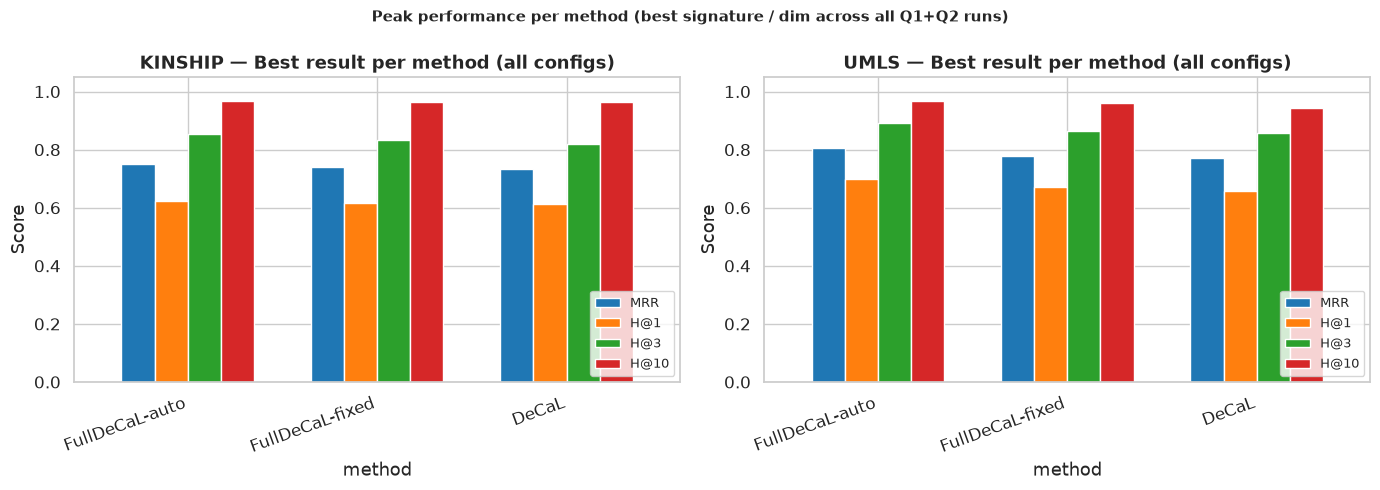

dataset          method  Test_MRR  Test_H@1  Test_H@3  Test_H@10
KINSHIP  FullDeCaL-auto   0.75009   0.62477   0.85475    0.96648
KINSHIP FullDeCaL-fixed   0.74151   0.61639   0.83380    0.96415
KINSHIP           DeCaL   0.73298   0.61220   0.81937    0.96276
   UMLS  FullDeCaL-auto   0.80571   0.69894   0.89259    0.96672
   UMLS FullDeCaL-fixed   0.77940   0.67247   0.86384    0.96142
   UMLS           DeCaL   0.77059   0.65658   0.85779    0.94402


In [12]:
all_metrics = ["Test_MRR", "Test_H@1", "Test_H@3", "Test_H@10"]
available   = [m for m in all_metrics if m in df_raw.columns]

# Best result per (dataset, method) aggregated over all configs
summary = (df_raw.groupby(["dataset", "method"])[available]
           .max()
           .reset_index()
           .sort_values(["dataset", "Test_MRR"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dataset in zip(axes, sorted(summary["dataset"].unique())):
    sub = summary[summary["dataset"] == dataset].set_index("method")
    sub[available].plot(kind="bar", ax=ax, width=0.7,
                        color=[sns.color_palette("tab10")[i] for i in range(len(available))],
                        edgecolor="white")
    ax.set_title(f"{dataset} — Best result per method (all configs)", fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.legend([m.replace("Test_","") for m in available], loc="lower right", fontsize=9)
    ax.set_ylim(0, 1.05)

fig.suptitle("Peak performance per method (best signature / dim across all Q1+Q2 runs)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
# plt.savefig(RESULTS_CSV.parent / "all_metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(summary.to_string(index=False))


## 8. Winner Map — Which Method Wins Per (Dataset × Embedding Dim)?

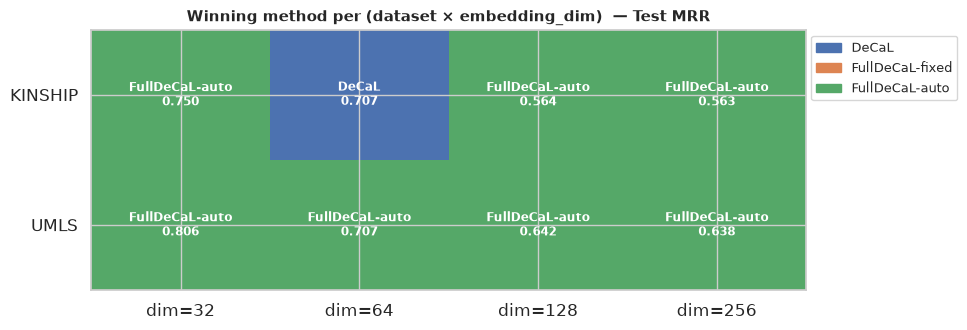

In [13]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# For each (dataset, dim), find the method with the highest Test_MRR
winner_rows = []
for (dataset, dim), grp in df_raw.groupby(["dataset", "embedding_dim"]):
    best_idx = grp["Test_MRR"].idxmax()
    winner_rows.append({
        "dataset": dataset,
        "embedding_dim": dim,
        "winner": grp.loc[best_idx, "method"],
        "best_MRR": grp.loc[best_idx, "Test_MRR"],
        "label": f"{grp.loc[best_idx, 'method']}\n{grp.loc[best_idx, 'Test_MRR']:.3f}",
    })

winner_df = pd.DataFrame(winner_rows)

METHOD_TO_INT = {"DeCaL": 0, "FullDeCaL-fixed": 1, "FullDeCaL-auto": 2}
winner_df["winner_int"] = winner_df["winner"].map(METHOD_TO_INT)

pivot_winner  = winner_df.pivot(index="dataset", columns="embedding_dim", values="winner_int")
pivot_label   = winner_df.pivot(index="dataset", columns="embedding_dim", values="label")

cmap = ListedColormap(["#4C72B0", "#DD8452", "#55A868"])

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(pivot_winner.values, cmap=cmap, vmin=-0.5, vmax=2.5, aspect="auto")

for i in range(pivot_winner.shape[0]):
    for j in range(pivot_winner.shape[1]):
        ax.text(j, i, pivot_label.values[i, j], ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold")

ax.set_xticks(range(len(pivot_winner.columns)))
ax.set_xticklabels([f"dim={d}" for d in pivot_winner.columns])
ax.set_yticks(range(len(pivot_winner.index)))
ax.set_yticklabels(pivot_winner.index)
ax.set_title("Winning method per (dataset × embedding_dim)  — Test MRR",
             fontweight="bold", fontsize=11)

legend_patches = [Patch(color=c, label=m) for m, c in PALETTE.items()]
ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.22, 1.0), fontsize=9)

plt.tight_layout()
# plt.savefig(RESULTS_CSV.parent / "winner_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Run the Experiment Suite

Run this cell to launch all training jobs from inside the notebook.  
Estimated time: ~15–40 min on CPU for 100 epochs (UMLS + KINSHIP are small).


In [ ]:
import subprocess, sys

# Change --epochs to a smaller number (e.g. 20) for a quick smoke test.
result = subprocess.run(
    [sys.executable, str(REPO / "experiments" / "decal_comparison.py"),
     "--epochs", "100",
     "--skip_existing"],
    capture_output=False,   # stream output to notebook stdout
)
print("Exit code:", result.returncode)
